In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
data=pd.read_csv("train_u6lujuX_CVtuZ9i.csv")
data.head()
data.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [36]:
data.info()
data.describe()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [39]:

data["Gender"]=data["Gender"].fillna(data["Gender"].mode()[0])
data["Married"]=data["Married"].fillna(data["Married"].mode()[0])
data["Self_Employed"]=data["Self_Employed"].fillna(data["Self_Employed"].mode()[0])
data["Dependents"]=data["Dependents"].fillna(data["Dependents"].mode()[0])

data["LoanAmount"]=data["LoanAmount"].fillna(data["LoanAmount"].median())
data["Loan_Amount_Term"]=data["Loan_Amount_Term"].fillna(data["Loan_Amount_Term"].median())
data["Credit_History"]=data["Credit_History"].fillna(data["Credit_History"].median())
data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [40]:
data=pd.get_dummies(data,columns=["Gender","Married","Education","Self_Employed","Property_Area"],drop_first=True)
data["Loan_Status"]=data["Loan_Status"].map({'Y':1,'N':0})

data=data.drop("Loan_ID",axis=1)
data["Dependents"]=data["Dependents"].replace("3+",3)
data

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,5849,0.0,128.0,360.0,1.0,1,True,False,False,False,False,True
1,1,4583,1508.0,128.0,360.0,1.0,0,True,True,False,False,False,False
2,0,3000,0.0,66.0,360.0,1.0,1,True,True,False,True,False,True
3,0,2583,2358.0,120.0,360.0,1.0,1,True,True,True,False,False,True
4,0,6000,0.0,141.0,360.0,1.0,1,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,2900,0.0,71.0,360.0,1.0,1,False,False,False,False,False,False
610,3,4106,0.0,40.0,180.0,1.0,1,True,True,False,False,False,False
611,1,8072,240.0,253.0,360.0,1.0,1,True,True,False,False,False,True
612,2,7583,0.0,187.0,360.0,1.0,1,True,True,False,False,False,True


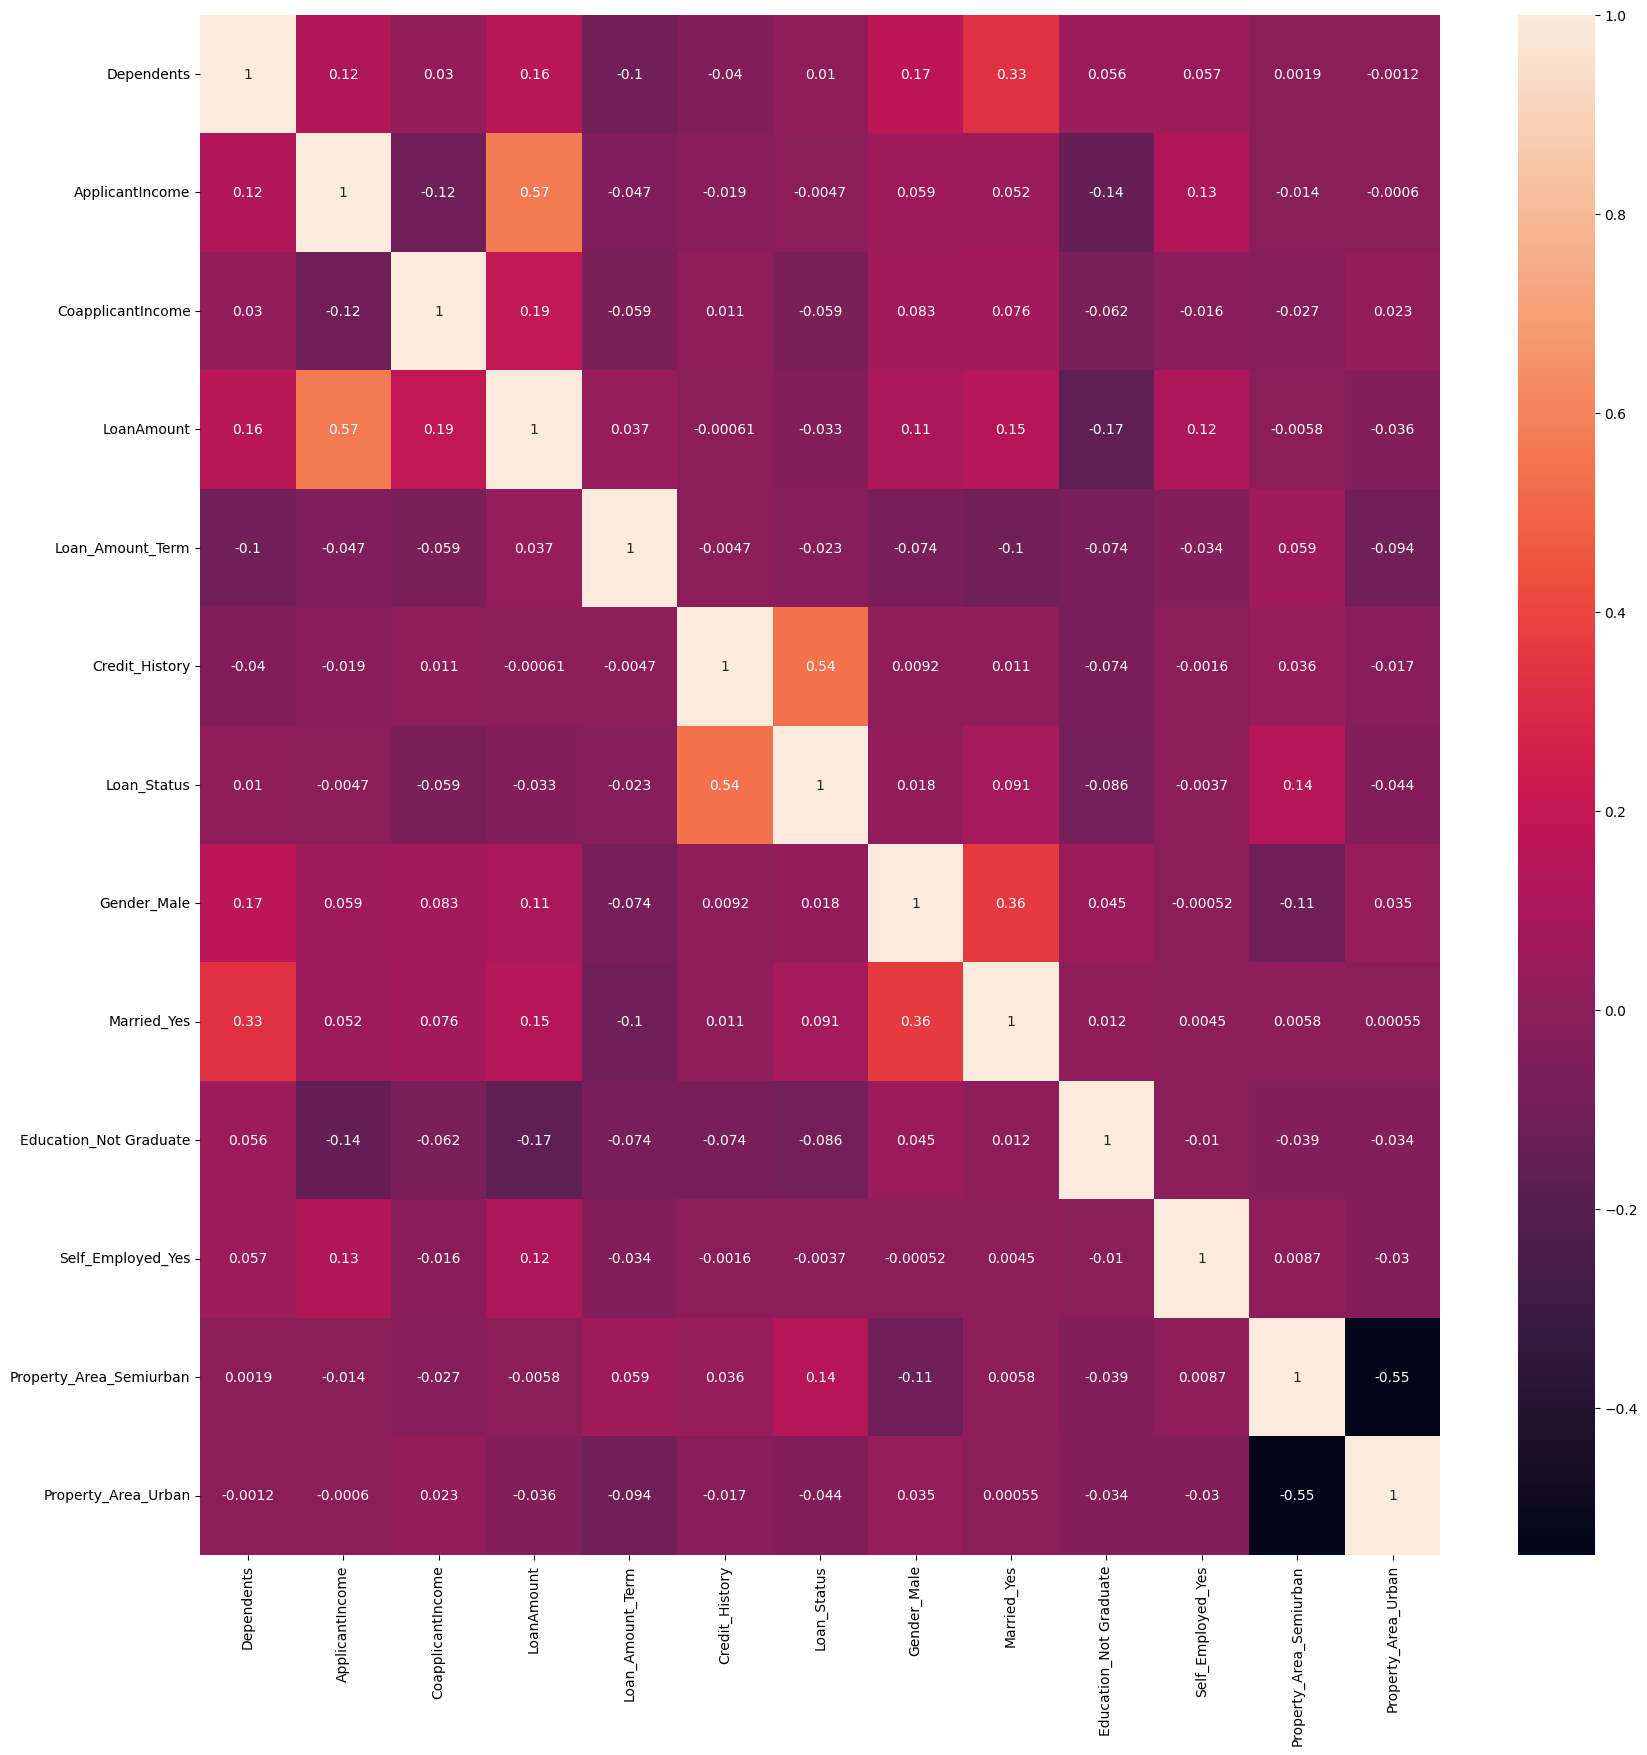

In [41]:
df=data.corr()
plt.figure(figsize=(20,20))
sns.heatmap(df,annot=True)
plt.show()

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from imblearn.over_sampling import SMOTE

In [43]:
X=data.drop(columns=["Loan_Status"],axis=1)
Y=data['Loan_Status']
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
print("\n======= BEFORE SMOTE =====\n")
Y_train.value_counts()


======= BEFORE SMOTE =====



Loan_Status
1    342
0    149
Name: count, dtype: int64

In [44]:
smote=SMOTE(random_state=42)
X_train,Y_train=smote.fit_resample(X_train,Y_train)
print("\n======= AFTER SMOTE =====\n")
Y_train.value_counts()


======= AFTER SMOTE =====



Loan_Status
0    342
1    342
Name: count, dtype: int64

In [45]:


models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()
}

standard=StandardScaler()
X_train=standard.fit_transform(X_train)
X_test=standard.transform(X_test)
print("\n====== Before the Tuning =======")
for name,models in models.items():
    models.fit(X_train,Y_train)
    y_test=models.predict(X_test)
    print(f"\n\t{name}\n")
    print("Accuracy:", accuracy_score(Y_test, y_test))
    
    print("Confusion Matrix:")
    print(confusion_matrix(Y_test, y_test))
    
    print("Classification Report:")
    print(classification_report(Y_test, y_test))




====== Before the Tuning =======

	Logistic Regression

Accuracy: 0.7886178861788617
Confusion Matrix:
[[22 21]
 [ 5 75]]
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.51      0.63        43
           1       0.78      0.94      0.85        80

    accuracy                           0.79       123
   macro avg       0.80      0.72      0.74       123
weighted avg       0.79      0.79      0.77       123


	Decision Tree

Accuracy: 0.7398373983739838
Confusion Matrix:
[[26 17]
 [15 65]]
Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.60      0.62        43
           1       0.79      0.81      0.80        80

    accuracy                           0.74       123
   macro avg       0.71      0.71      0.71       123
weighted avg       0.74      0.74      0.74       123


	Random Forest

Accuracy: 0.7723577235772358
Confusion Matrix:
[[20 23]
 [ 5 75]]
Classificat

In [46]:

print("\n========== AFTER TUNING ==========")

param_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid_lr = GridSearchCV(LogisticRegression(max_iter=6000), param_lr, cv=5)
grid_lr.fit(X_train, Y_train)

print("\n\tTUNED LOGISTIC REGRESSION\n")
print("Best Params:", grid_lr.best_params_)
y_pred = grid_lr.predict(X_test)
print("Accuracy:", accuracy_score(Y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(Y_test, y_pred))
    
print("Classification Report:")
print(classification_report(Y_test, y_pred))

param_dt = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(DecisionTreeClassifier(), param_dt, cv=5)
grid_dt.fit(X_train, Y_train)

print("\n\tTUNED DECISION TREE\n")
print("Best Params:", grid_dt.best_params_)
y_pred = grid_dt.predict(X_test)
print("Accuracy:", accuracy_score(Y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(Y_test, y_pred))
    
print("Classification Report:")
print(classification_report(Y_test, y_pred))

param_rf = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(RandomForestClassifier(), param_rf, cv=5)
grid_rf.fit(X_train, Y_train)

print("\n\tTUNED RANDOM FOREST\n")
print("Best Params:", grid_rf.best_params_)
y_pred = grid_rf.predict(X_test)
print("Accuracy:", accuracy_score(Y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(Y_test, y_pred))
    
print("Classification Report:")
print(classification_report(Y_test, y_pred))




param_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(KNeighborsClassifier(), param_knn, cv=5)

grid_knn.fit(X_train, Y_train)
print("\n\tTUNED KNEIGHBOR\n")
print("Best Params:", grid_knn.best_params_)
y_pred = grid_knn.predict(X_test)
print("Accuracy:", accuracy_score(Y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(Y_test, y_pred))
    
print("Classification Report:")
print(classification_report(Y_test, y_pred))


========== AFTER TUNING ==========

	TUNED LOGISTIC REGRESSION

Best Params: {'C': 0.1, 'solver': 'lbfgs'}
Accuracy: 0.7886178861788617
Confusion Matrix:
[[22 21]
 [ 5 75]]
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.51      0.63        43
           1       0.78      0.94      0.85        80

    accuracy                           0.79       123
   macro avg       0.80      0.72      0.74       123
weighted avg       0.79      0.79      0.77       123


	TUNED DECISION TREE

Best Params: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2}
Accuracy: 0.7560975609756098
Confusion Matrix:
[[23 20]
 [10 70]]
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.53      0.61        43
           1       0.78      0.88      0.82        80

    accuracy                           0.76       123
   macro avg       0.74      0.70      0.71       123
weighted avg    